# Tugas 9 | Dataset Facebook

## Deteksi Komunitas Pertemanan Facebook
### Menggunakan NetworkX + Louvain Method

Notebook ini melakukan:
- Load dataset facebook_combined.txt
- Analisis dasar graph
- Deteksi komunitas dengan metode Louvain (python-louvain)
- Visualisasi graph komunitas
- Menyimpan hasil komunitas sebagai CSV dan gambar PNG


import library

In [10]:
!pip install networkx matplotlib pandas python-louvain



[notice] A new release of pip is available: 24.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
import os
import math
from collections import Counter

import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

try:
    import community as community_package
    from community import community_louvain
except Exception:
    import community_louvain


load dataset

In [12]:
input_file = "facebook_combined.txt"

# Load graph
G = nx.read_edgelist(input_file, nodetype=int)

print("Graph berhasil dimuat!")
print("Jumlah Node :", G.number_of_nodes())
print("Jumlah Edge :", G.number_of_edges())


Graph berhasil dimuat!
Jumlah Node : 4039
Jumlah Edge : 88234


analisis dasar graph

In [13]:
degrees = dict(G.degree())

stats = {
    "nodes": G.number_of_nodes(),
    "edges": G.number_of_edges(),
    "avg_degree": sum(degrees.values()) / G.number_of_nodes(),
    "density": nx.density(G),
    "top_10_by_degree": sorted(degrees.items(), key=lambda x: x[1], reverse=True)[:10]
}

print("=== ANALISIS DASAR GRAF ===")
for k, v in stats.items():
    print(k, ":", v)


=== ANALISIS DASAR GRAF ===
nodes : 4039
edges : 88234
avg_degree : 43.69101262688784
density : 0.010819963503439287
top_10_by_degree : [(107, 1045), (1684, 792), (1912, 755), (3437, 547), (0, 347), (2543, 294), (2347, 291), (1888, 254), (1800, 245), (1663, 235)]


plot degree distribution

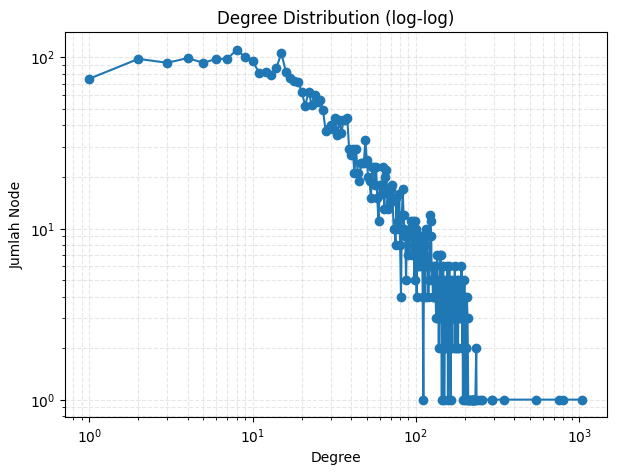

In [14]:
degree_vals = [d for _, d in G.degree()]
degree_counts = Counter(degree_vals)

deg, cnt = zip(*sorted(degree_counts.items()))

plt.figure(figsize=(7,5))
plt.loglog(deg, cnt, marker="o")
plt.xlabel("Degree")
plt.ylabel("Jumlah Node")
plt.title("Degree Distribution (log-log)")
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.show()


deteksi komunitas (louvain)

In [15]:
print("Menjalankan algoritma Louvain...")

partition = community_louvain.best_partition(G)
modularity = community_louvain.modularity(partition, G)
num_communities = len(set(partition.values()))

print("Jumlah Komunitas :", num_communities)
print("Modularity :", modularity)


Menjalankan algoritma Louvain...
Jumlah Komunitas : 16
Modularity : 0.8349405290865817


simpan hasil ke csv

In [16]:
df = pd.DataFrame(list(partition.items()), columns=["node", "community"])
df = df.sort_values(["community", "node"]).reset_index(drop=True)

df.to_csv("communities.csv", index=False)

print("File communities.csv telah disimpan.")

# Ringkasan ukuran komunitas
summary = df["community"].value_counts().sort_values(ascending=False)
summary


File communities.csv telah disimpan.


community
14    548
5     535
1     432
8     432
4     423
2     354
6     323
11    237
0     226
15    206
7     127
10     73
13     60
12     25
3      19
9      19
Name: count, dtype: int64

visualisasi komunitas

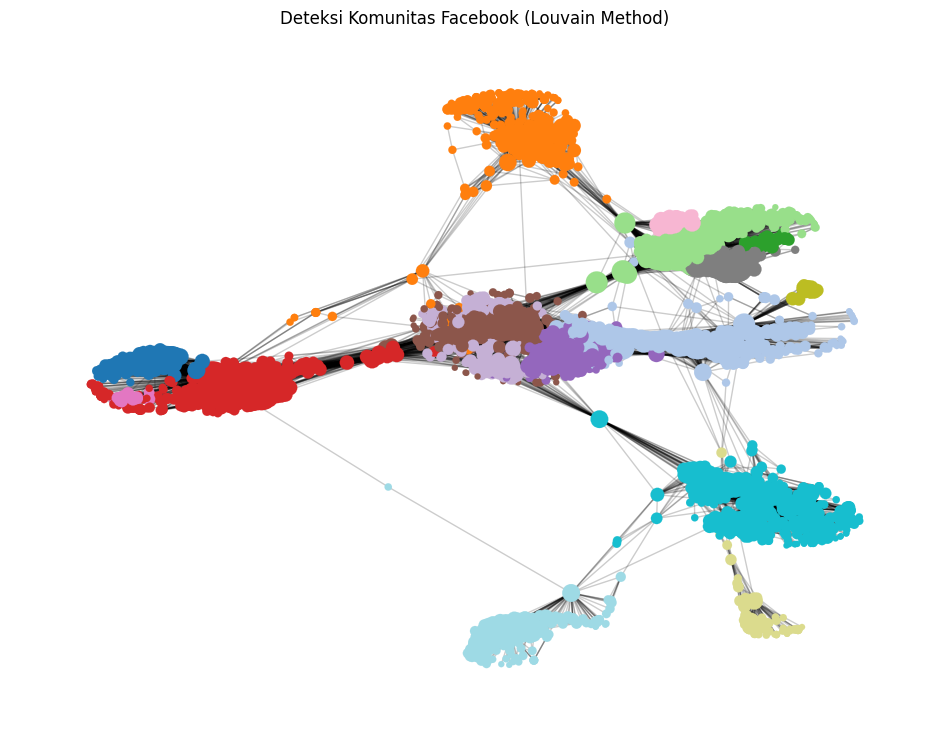

In [17]:
plt.figure(figsize=(12,9))

# Layout posisi node
pos = nx.spring_layout(G, seed=42)

# Warna komunitas
communities = list(sorted(set(partition.values())))
mapping = {c:i for i,c in enumerate(communities)}
node_colors = [mapping[partition[n]] for n in G.nodes()]

# Ukuran node berdasarkan degree
node_sizes = [max(10, math.sqrt(dict(G.degree())[n]) * 20) for n in G.nodes()]

nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    cmap=plt.get_cmap("tab20"),
    node_size=node_sizes,
    linewidths=0.1
)

nx.draw_networkx_edges(G, pos, alpha=0.2)

plt.title("Deteksi Komunitas Facebook (Louvain Method)")
plt.axis("off")
plt.show()


simpan gambar visual

In [18]:
plt.figure(figsize=(12,9))
nx.draw_networkx_nodes(G, pos, node_color=node_colors, cmap=plt.get_cmap("tab20"), node_size=node_sizes)
nx.draw_networkx_edges(G, pos, alpha=0.2)
plt.title("Deteksi Komunitas Facebook (Louvain Method)")
plt.axis("off")

plt.savefig("facebook_communities.png", dpi=300)
plt.close()

print("Gambar disimpan sebagai facebook_communities.png")


Gambar disimpan sebagai facebook_communities.png


eda

In [19]:
# =============================
# 1. IMPORT LIBRARIES
# =============================
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# =============================
# 2. LOAD DATASET
# =============================
# Pastikan file berada di direktori yang sama
file_path = "facebook_combined.txt"

df = pd.read_csv(file_path, sep=" ", names=["source", "target"])
df.head()


,source,target
0,0,1
1,0,2
2,0,3
3,0,4
4,0,5


In [20]:
# =============================
# 3. BASIC INFO
# =============================
print("Jumlah baris (edges):", len(df))
print("5 baris awal:")
print(df.head())


Jumlah baris (edges): 88234
5 baris awal:
   source  target
0       0       1
1       0       2
2       0       3
3       0       4
4       0       5


In [21]:
# =============================
# 4. BUILD GRAPH
# =============================
G = nx.from_pandas_edgelist(df, "source", "target")

print("Jumlah akun (nodes):", G.number_of_nodes())
print("Jumlah pertemanan (edges):", G.number_of_edges())


Jumlah akun (nodes): 4039
Jumlah pertemanan (edges): 88234


Rata-rata jumlah teman: 43.69101262688784
Maksimal jumlah teman: 1045


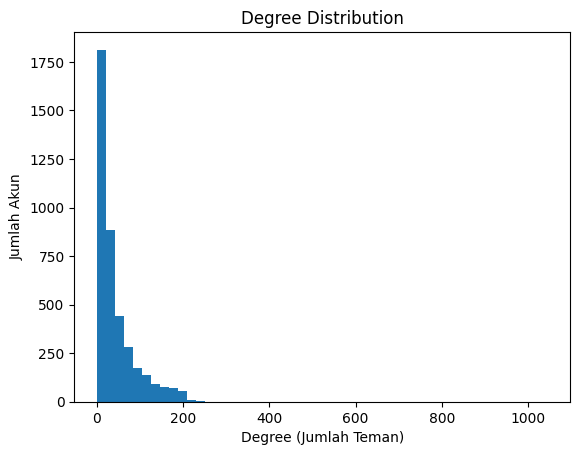

In [22]:
# =============================
# 5. DEGREE ANALYSIS
# =============================
degree_list = [deg for node, deg in G.degree()]

print("Rata-rata jumlah teman:", sum(degree_list)/len(degree_list))
print("Maksimal jumlah teman:", max(degree_list))

plt.hist(degree_list, bins=50)
plt.title("Degree Distribution")
plt.xlabel("Degree (Jumlah Teman)")
plt.ylabel("Jumlah Akun")
plt.show()


In [23]:
# =============================
# 6. CONNECTED COMPONENTS
# =============================
components = nx.connected_components(G)
components = list(components)

print("Jumlah komponen terhubung:", len(components))

largest_cc = max(components, key=len)
print("Ukuran komponen terbesar:", len(largest_cc))


Jumlah komponen terhubung: 1
Ukuran komponen terbesar: 4039


In [24]:
# =============================
# 7. CLUSTERING COEFFICIENT
# =============================
avg_clustering = nx.average_clustering(G)
print("Average Clustering Coefficient:", avg_clustering)


Average Clustering Coefficient: 0.6055467186200876


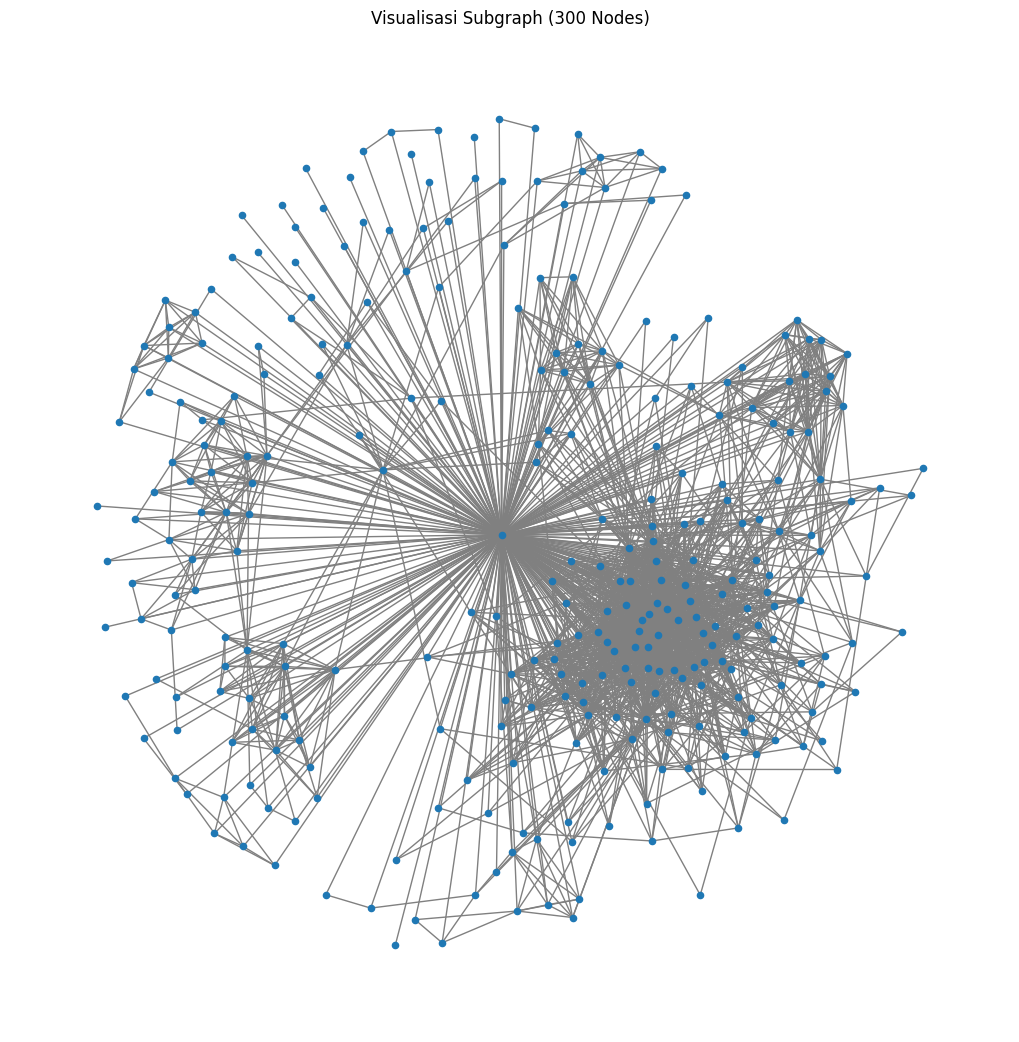

In [25]:
# =============================
# 8. VISUALISASI MINI GRAPH
# (Plot sebagian kecil saja karena graph-nya besar)
# =============================

sub_nodes = list(G.nodes())[:300]  # ambil 300 node pertama
H = G.subgraph(sub_nodes)

plt.figure(figsize=(10, 10))
nx.draw_spring(H, node_size=20, edge_color='gray')
plt.title("Visualisasi Subgraph (300 Nodes)")
plt.show()


**tugas**


ada node 0 - 4038, node 5 siapa temanny ada

ada komunitas sapa aja

siapa teman nya






In [ ]:
import pandas as pd
import networkx as nx
from community import community_louvain  # pip install python-louvain

# Load dataset
df = pd.read_csv("facebook_combined.txt", sep=" ", names=["source", "target"])

# Build graph
G = nx.from_pandas_edgelist(df, "source", "target")

print("Total node:", G.number_of_nodes())
print("Total edge:", G.number_of_edges())


Total node: 4039
Total edge: 88234


deteksi komunitas

In [27]:
# Louvain community detection
partition = community_louvain.best_partition(G)

# Komunitas tempat node 5 berada
node_5_community = partition[5]
print("Node 5 berada di komunitas:", node_5_community)


Node 5 berada di komunitas: 0


Ambil Semua Anggota Komunitas Node 5

In [28]:
community_members = [node for node, comm in partition.items() if comm == node_5_community]

print("Jumlah anggota komunitas:", len(community_members))
print("Anggota komunitas:", community_members[:50], "...")  # tampilkan 50 pertama


Jumlah anggota komunitas: 354
Anggota komunitas: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50] ...


cari teman dari node 5 (neighbors)

In [29]:
neighbors_5 = list(G.neighbors(5))
print("Teman langsung node 5:", neighbors_5)


Teman langsung node 5: [0, 87, 122, 156, 158, 169, 180, 187, 204, 213, 235, 315, 316]


temna node 5 yang satu komunitas saja

In [30]:
friends_same_community = [n for n in neighbors_5 if partition[n] == node_5_community]

print("Teman Node 5 yang berada di komunitas yang sama:")
print(friends_same_community)


Teman Node 5 yang berada di komunitas yang sama:
[0, 87, 122, 156, 158, 169, 180, 187, 204, 213, 235, 315, 316]


- Ambil community members dari komunitas node 5

- Buat subgraph

- Jalankan Louvain lagi pada subgraph

- Lihat struktur sub-komunitas

In [34]:
# --- SUB KOMUNITAS ---

# Ambil anggota komunitas node 5
community_members = [n for n, c in partition.items() if c == node_5_community]

# Buat subgraph komunitas tersebut
subG = G.subgraph(community_members)

# Jalankan Louvain pada subgraph
sub_partition = community_louvain.best_partition(subG)

# Hitung jumlah sub-komunitas
num_subcom = len(set(sub_partition.values()))
print("Jumlah sub-komunitas:", num_subcom)

# Ukuran sub-komunitas
sub_sizes = pd.Series(sub_partition).value_counts()
print(sub_sizes)


Jumlah sub-komunitas: 9
0    109
3     82
8     35
7     35
5     31
2     22
6     13
1     13
4     10
Name: count, dtype: int64


tingkat keterhubungan (Ciri)

In [35]:
density = nx.density(subG)
print("Density komunitas node 5:", density)


Density komunitas node 5: 0.046582071223905036


- Density = 0.15 → komunitas padat

- Density = 0.01 → komunitas longgar

Semakin padat → lebih mirip “circle of close friends”.

tokoh penting

In [36]:
deg_central = nx.degree_centrality(subG)
top10 = sorted(deg_central.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top node paling sentral di komunitas node 5:", top10)


Top node paling sentral di komunitas node 5: [(0, 0.979942693409742), (56, 0.22063037249283668), (67, 0.2148997134670487), (271, 0.20916905444126074), (322, 0.20343839541547276), (25, 0.1977077363896848), (26, 0.19484240687679083), (252, 0.18624641833810887), (277, 0.18624641833810887), (21, 0.1833810888252149)]


Visualisasikan hanya komunitas 5:

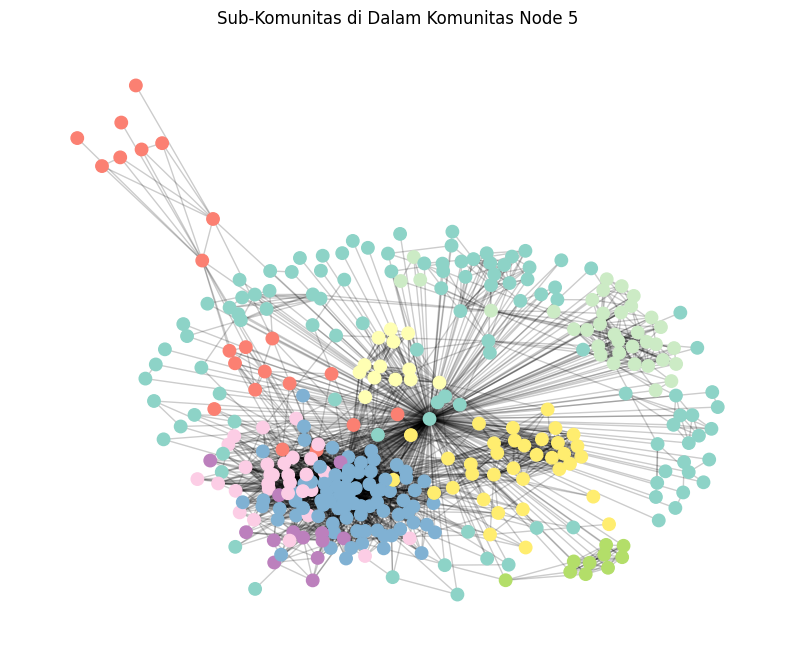

In [37]:
plt.figure(figsize=(10, 8))
pos2 = nx.spring_layout(subG, seed=42)

sub_colors = [sub_partition[n] for n in subG.nodes()]

nx.draw_networkx_nodes(subG, pos2, node_color=sub_colors, cmap=plt.cm.Set3, node_size=80)
nx.draw_networkx_edges(subG, pos2, alpha=0.2)
plt.title("Sub-Komunitas di Dalam Komunitas Node 5")
plt.axis("off")
plt.show()
